#Exercícios



1.   Implemente uma rotina que compara no banco de dados utilizado inicialmente neste notebook, as classes (labels) originais e as preditas e identifica os dados que tiveram predições erradas.
2.   Plotar essas predições erradas junto com o banco de dados original, de forma a visualisar os resultados.
3. Modificar o parêmetro `cluster_std` da função `make_blobs` para 0.9, 1.2 e 1.8.
4. Observar se o preditor de número de núcleos `KElbowVisualizer` consegue prever o número de núclos corretamente em todas as situações.
5. Qual o princípio de funcionamento do algoritmo K-Means?



In [11]:
# Exercício 1

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

dataset, classes = make_blobs(
    n_samples=600,
    n_features=2,
    centers=4,
    cluster_std=0.7,
    random_state=0
)

df = pd.DataFrame(dataset, columns=['var1', 'var2'])

kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=10,
    random_state=0
)

kmeans.fit(df)

predict_classes = kmeans.labels_

erros = []

for i in range(len(classes)):
    if classes[i] != predict_classes[i]:
        erros.append(i)

print("Quantidade de dados diferentes:", len(erros))
print("Índices dos dados:", erros)

Quantidade de dados diferentes: 450
Índices dos dados: [1, 4, 5, 6, 7, 8, 9, 11, 12, 14, 15, 17, 19, 20, 21, 22, 23, 24, 25, 27, 28, 29, 30, 31, 34, 35, 38, 39, 41, 42, 43, 44, 45, 47, 50, 51, 53, 54, 55, 56, 57, 58, 59, 61, 62, 63, 65, 67, 68, 69, 70, 71, 73, 74, 76, 77, 78, 80, 81, 82, 84, 85, 87, 88, 90, 91, 93, 95, 96, 97, 99, 100, 101, 103, 104, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 120, 121, 122, 123, 124, 125, 126, 127, 130, 131, 132, 133, 134, 136, 137, 138, 139, 140, 142, 144, 145, 146, 147, 148, 149, 150, 151, 153, 154, 155, 156, 157, 158, 159, 161, 164, 168, 169, 171, 172, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 192, 193, 194, 195, 196, 197, 199, 201, 202, 204, 205, 206, 207, 208, 209, 210, 211, 212, 214, 216, 217, 218, 220, 222, 223, 224, 226, 227, 228, 229, 230, 232, 233, 235, 236, 238, 239, 243, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 261, 263, 266, 267, 268, 269, 270, 271, 27

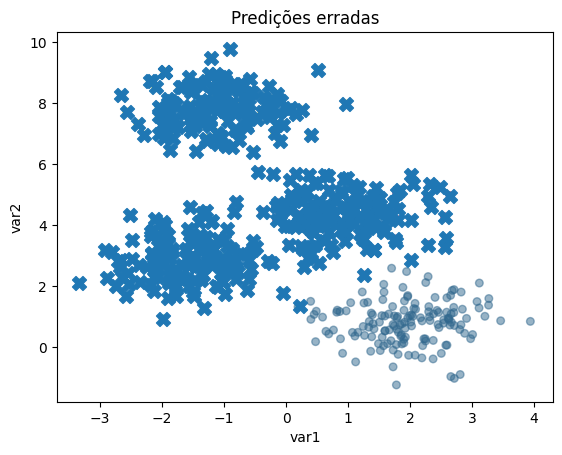

In [12]:
# Exercício 2

import matplotlib.pyplot as plt

plt.scatter(
    dataset[:, 0],
    dataset[:, 1],
    c=classes,
    s=30,
    alpha=0.5
)

plt.scatter(
    dataset[erros, 0],
    dataset[erros, 1],
    marker='X',
    s=100
)

plt.xlabel('var1')
plt.ylabel('var2')
plt.title('Predições erradas')
plt.show()

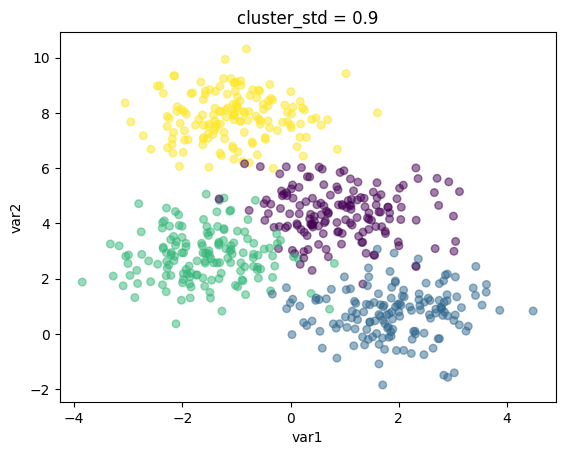

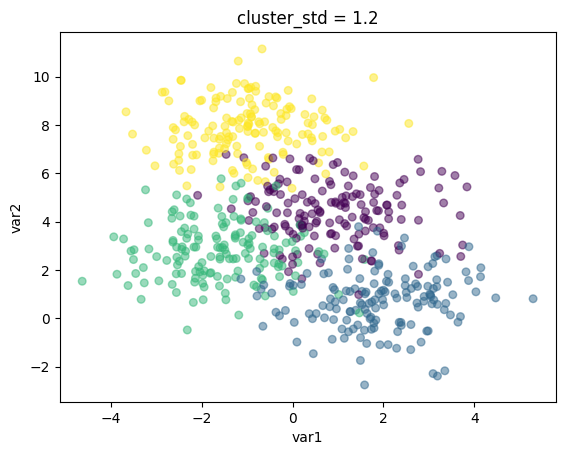

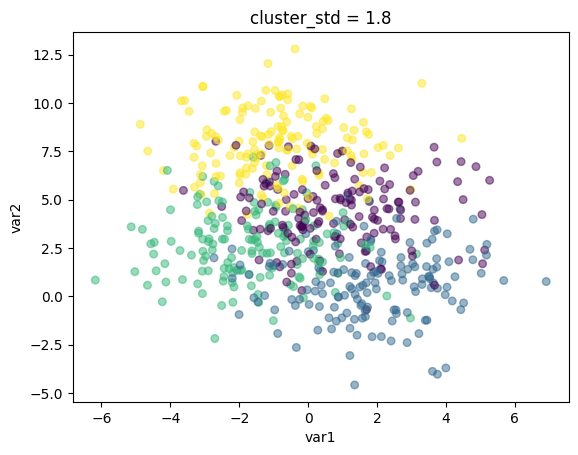

In [13]:
# Exercício 3

from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

valores = [0.9, 1.2, 1.8]

for valor in valores:
    dataset_novo, classes_novas = make_blobs(
        n_samples=600,
        n_features=2,
        centers=4,
        cluster_std=valor,
        random_state=0
    )

    plt.scatter(
        dataset_novo[:, 0],
        dataset_novo[:, 1],
        c=classes_novas,
        s=30,
        alpha=0.5
    )

    plt.xlabel('var1')
    plt.ylabel('var2')
    plt.title('cluster_std = ' + str(valor))
    plt.show()

cluster_std = 0.9 | K encontrado = 4


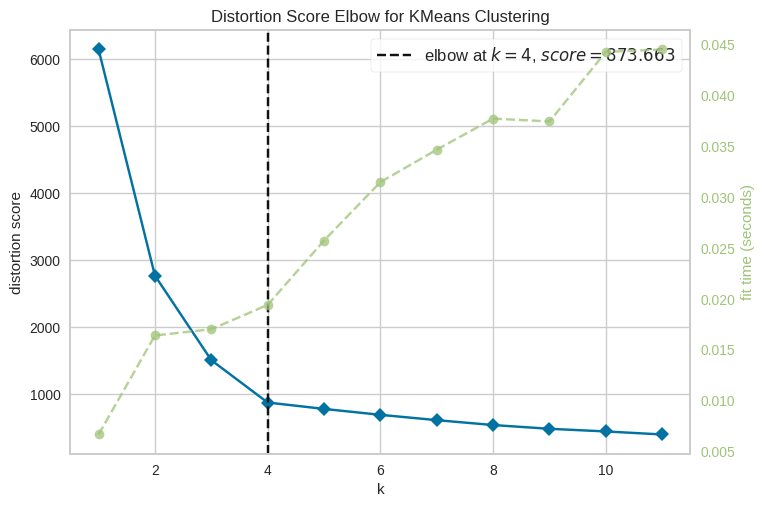

cluster_std = 1.2 | K encontrado = 4


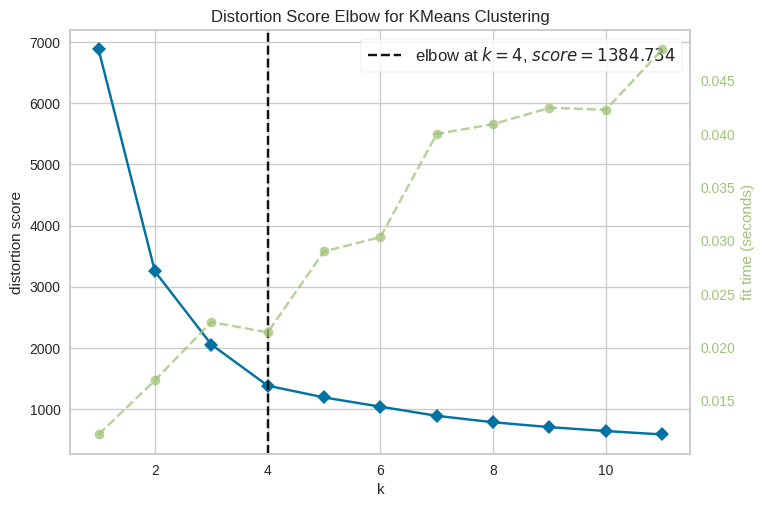

cluster_std = 1.8 | K encontrado = 4


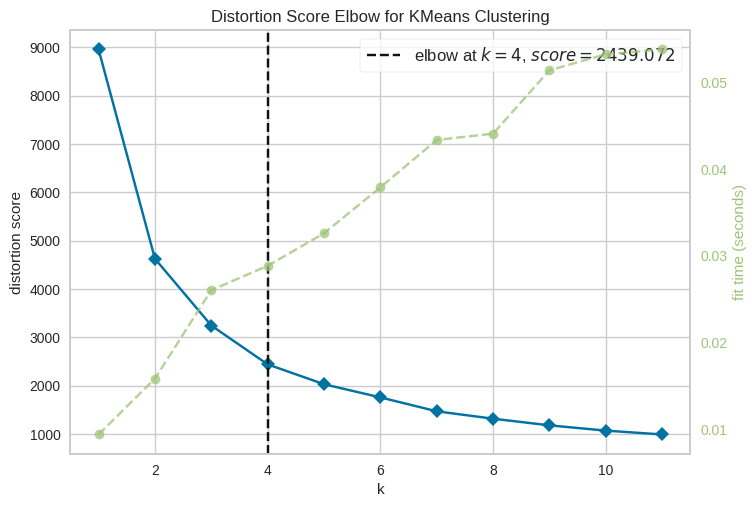

In [14]:
# Exercício 4

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

valores = [0.9, 1.2, 1.8]

for valor in valores:
    dataset_novo, classes_novas = make_blobs(
        n_samples=600,
        n_features=2,
        centers=4,
        cluster_std=valor,
        random_state=0
    )

    model = KMeans(n_init=20, random_state=0)

    visualizer = KElbowVisualizer(
        model,
        k=(1, 12)
    )

    visualizer.fit(dataset_novo)

    print(
        "cluster_std =", valor,
        "| K encontrado =", visualizer.elbow_value_
    )

    visualizer.show()

Exercício 5

O K-Means funciona dividindo os dados em K grupos. Primeiro, ele escolhe alguns pontos para serem os centroides. Depois, verifica qual centroide está mais próximo de cada dado e coloca cada um no grupo correspondente. Em seguida, calcula novamente a média dos pontos de cada grupo para atualizar os centroides. Esse processo se repete até que os grupos não mudem mais.